Mean Squared Error: 98.60005296355203
R2 Score: 0.8232290645252092


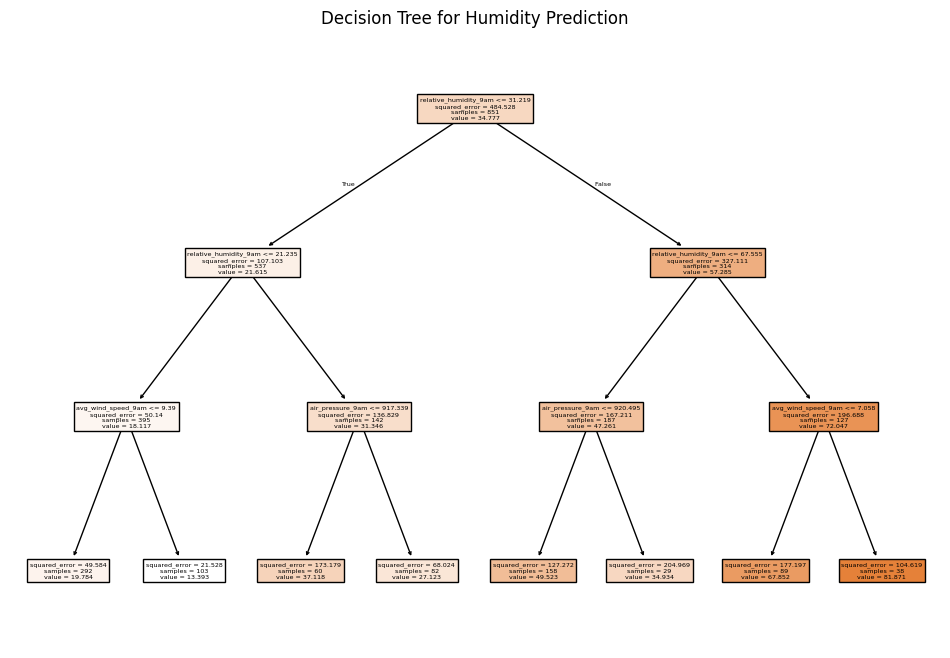

In [5]:
# Decision Tree Regression - Predict Humidity

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = pd.read_csv("daily_weather.csv")

# Keep only numeric columns and remove missing values
data = data.select_dtypes(include=['float64', 'int64']).dropna()

# Define features (X) and target (y)
X = data.drop('relative_humidity_3pm', axis=1)
y = data['relative_humidity_3pm']

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree model (limit depth for simple tree)
model = DecisionTreeRegressor(max_depth=3, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, filled=True)
plt.title("Decision Tree for Humidity Prediction")
plt.show()

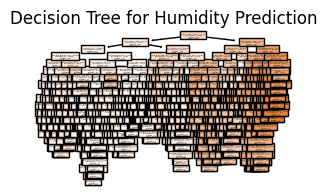